# Program 4 — Lane Detection System

**Aim:** Implement and evaluate a Lane Detection System using OpenCV to detect lane
markings from a road image.

**Method:** Canny edge detection → region of interest mask → probabilistic Hough
transform → split the line segments into left/right by slope → fit one average
line per side.

In [1]:
import cv2
import numpy as np

import matplotlib.pyplot as plt


def show(img, title):
    """Display a BGR or grayscale OpenCV image inside the notebook."""
    plt.figure(figsize=(12, 7))
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


Image shape: (370, 1280, 3)


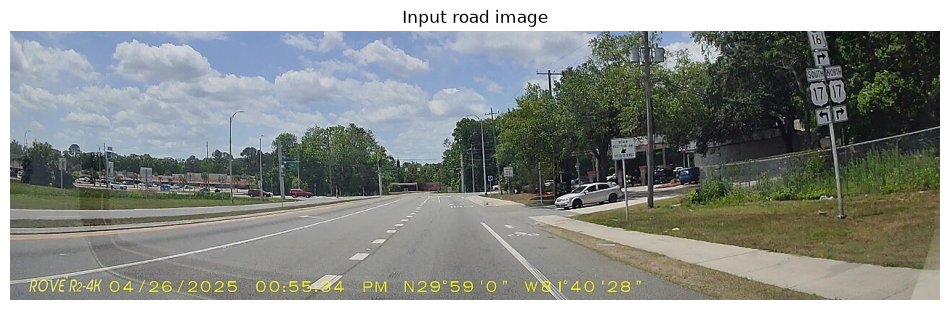

In [2]:
image = cv2.imread("road.jpg")
if image is None:
    raise FileNotFoundError("road.jpg not found")

output = image.copy()
print("Image shape:", image.shape)
show(image, "Input road image")

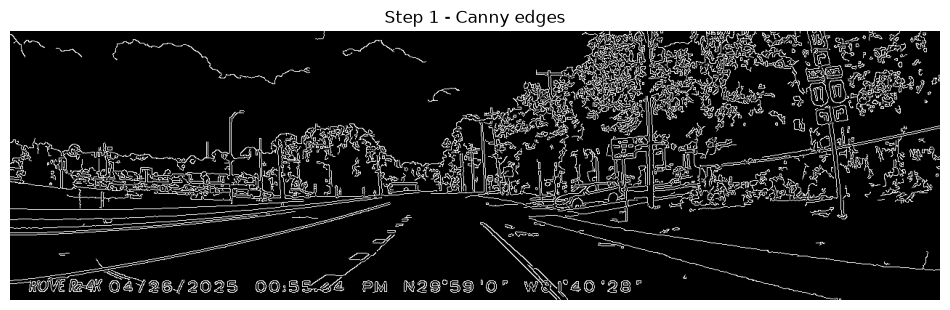

In [3]:
# Step 1 - grayscale, blur and Canny edges
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150)

show(edges, "Step 1 - Canny edges")

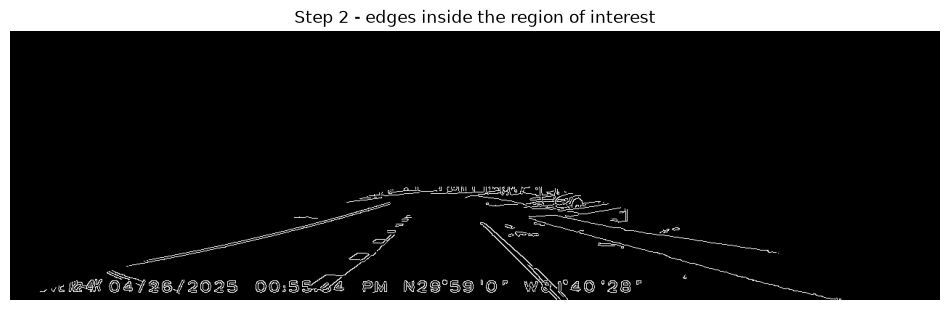

In [4]:
# Step 2 - keep only the road region in front of the car
h, w = edges.shape
mask = np.zeros_like(edges)

polygon = np.array([[
    (0, h),
    (w, h),
    (int(0.58 * w), int(0.58 * h)),
    (int(0.42 * w), int(0.58 * h))
]], dtype=np.int32)

cv2.fillPoly(mask, polygon, 255)
roi_edges = cv2.bitwise_and(edges, mask)

show(roi_edges, "Step 2 - edges inside the region of interest")

In [5]:
# Step 3 - Hough transform, then split segments by slope
lines = cv2.HoughLinesP(roi_edges, rho=1, theta=np.pi / 180,
                        threshold=30, minLineLength=30, maxLineGap=100)

left_lines = []
right_lines = []

if lines is not None:
    for x1, y1, x2, y2 in lines.reshape(-1, 4):

        if x2 == x1:
            continue

        slope = (y2 - y1) / (x2 - x1)

        if -1.5 < slope < -0.4:          # negative slope = left lane
            left_lines.append((x1, y1, x2, y2))
        elif 0.4 < slope < 1.5:          # positive slope = right lane
            right_lines.append((x1, y1, x2, y2))

print("Left lane segments :", len(left_lines))
print("Right lane segments:", len(right_lines))

Left lane segments : 3
Right lane segments: 3


In [6]:
# Step 4 - fit a single average line for each side
def average_line(lines, y_bottom, y_top):

    if len(lines) == 0:
        return None

    xs = []
    ys = []
    for x1, y1, x2, y2 in lines:
        xs.extend([x1, x2])
        ys.extend([y1, y2])

    slope, intercept = np.polyfit(xs, ys, 1)
    if abs(slope) < 1e-6:
        return None

    x_bottom = int((y_bottom - intercept) / slope)
    x_top = int((y_top - intercept) / slope)
    return x_bottom, y_bottom, x_top, y_top


y_bottom = h - 1
y_top = int(0.60 * h)

left_lane = average_line(left_lines, y_bottom, y_top)
right_lane = average_line(right_lines, y_bottom, y_top)

print("Left lane :", left_lane)
print("Right lane:", right_lane)

Left lane : (425, 369, 588, 222)
Right lane: (765, 369, 604, 222)


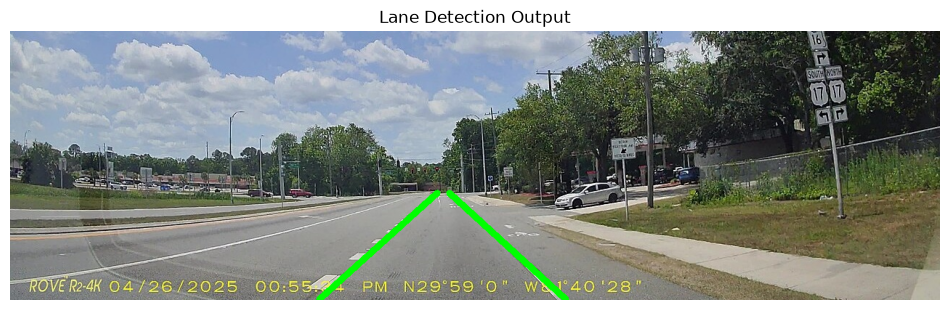

In [7]:
# Step 5 - draw the detected lanes
for lane in [left_lane, right_lane]:
    if lane is not None:
        x1, y1, x2, y2 = lane
        cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 8)

cv2.imwrite("output.jpg", output)
show(output, "Lane Detection Output")